# ATTENTION MECHANISM

In [1]:
import numpy as np
import torch
import sys
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
sys.path.append(os.path.abspath('..'))



In [2]:
from src.attention import ScaledDotProductAttention

## Implementing Linear Projections

In [3]:
batch_size = 2
seq_len = 5
d_model = 16


X = torch.randn(batch_size, seq_len, d_model)
print(f"Input X shape: {X.shape}")

Input X shape: torch.Size([2, 5, 16])


In [4]:
attention = ScaledDotProductAttention(16)

q,k,v = attention.compute_qkv(X)

Q shape is :torch.Size([2, 5, 16])
K shape is :torch.Size([2, 5, 16])
V shape is :torch.Size([2, 5, 16])


In [5]:
scores = attention.compute_scores(q,k)

probs,weights = attention.softmax(scores,v)
print(probs[0])


sums = torch.sum(probs, dim=-1)
print(sums)

tensor([[-0.3785, -0.2003,  0.1014, -0.1138, -0.6402,  0.1392, -0.0864, -0.1507,
          0.1939,  0.2316,  0.2412, -0.1856,  0.2006,  0.1625, -0.3638, -0.1670],
        [-0.3522, -0.2746,  0.1472, -0.1270, -0.6479,  0.0688, -0.0290, -0.1212,
          0.2898,  0.2034,  0.2351, -0.1760,  0.2286,  0.2137, -0.4334, -0.1453],
        [-0.3995, -0.2467,  0.1165, -0.1925, -0.7048,  0.1002, -0.1252, -0.1656,
          0.2557,  0.2078,  0.2187, -0.0833,  0.2731,  0.2005, -0.3472, -0.1430],
        [-0.4251, -0.0664,  0.0717, -0.2303, -0.7334,  0.1353, -0.3272, -0.1641,
          0.1867,  0.2782,  0.2307, -0.0630,  0.2933,  0.2315, -0.2302, -0.1540],
        [-0.2747, -0.3913,  0.1839, -0.0483, -0.6039,  0.0452,  0.1568, -0.1391,
          0.3112,  0.1678,  0.2381, -0.2265,  0.1595,  0.1283, -0.5505, -0.1398]],
       grad_fn=<SelectBackward0>)
tensor([[-1.0160, -0.9198, -1.0353, -0.9663, -0.9833],
        [-1.2714, -1.4228, -1.3445, -1.5487, -1.3879]], grad_fn=<SumBackward1>)


In [6]:
output,weights = attention.forward(X)

print(output.shape)
print(output)





Q shape is :torch.Size([2, 5, 16])
K shape is :torch.Size([2, 5, 16])
V shape is :torch.Size([2, 5, 16])
torch.Size([2, 5, 16])
tensor([[[-3.7850e-01, -2.0031e-01,  1.0141e-01, -1.1377e-01, -6.4021e-01,
           1.3916e-01, -8.6425e-02, -1.5067e-01,  1.9388e-01,  2.3157e-01,
           2.4116e-01, -1.8559e-01,  2.0059e-01,  1.6253e-01, -3.6380e-01,
          -1.6704e-01],
         [-3.5218e-01, -2.7458e-01,  1.4716e-01, -1.2695e-01, -6.4789e-01,
           6.8838e-02, -2.8969e-02, -1.2123e-01,  2.8980e-01,  2.0343e-01,
           2.3508e-01, -1.7596e-01,  2.2863e-01,  2.1366e-01, -4.3337e-01,
          -1.4531e-01],
         [-3.9949e-01, -2.4666e-01,  1.1653e-01, -1.9248e-01, -7.0485e-01,
           1.0016e-01, -1.2520e-01, -1.6556e-01,  2.5573e-01,  2.0776e-01,
           2.1868e-01, -8.3327e-02,  2.7312e-01,  2.0049e-01, -3.4724e-01,
          -1.4297e-01],
         [-4.2511e-01, -6.6386e-02,  7.1683e-02, -2.3030e-01, -7.3337e-01,
           1.3529e-01, -3.2717e-01, -1.6408e-01,  

## Attention Heatmaps

In [7]:
numpy_array = weights[0].detach().cpu().numpy()

print(numpy_array.shape)
print(numpy_array)

(5, 5)
[[0.2078653  0.22455165 0.14446385 0.24094026 0.18217897]
 [0.1932394  0.20885396 0.18300396 0.19359201 0.22131069]
 [0.16764303 0.24500327 0.205641   0.22485784 0.15685487]
 [0.17840193 0.15690154 0.22133496 0.3327991  0.11056247]
 [0.16652848 0.26088983 0.12686875 0.14478551 0.3009275 ]]


In [8]:
# Dummy words for our 5-token sequence
words = ["The", "animal", "was", "very", "tired"]

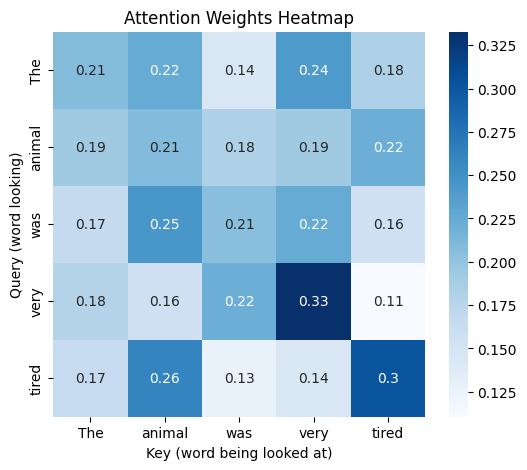

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(numpy_array,annot=True,cmap='Blues',xticklabels=words,yticklabels=words)


plt.title("Attention Weights Heatmap")
plt.xlabel("Key (word being looked at)")
plt.ylabel("Query (word looking)")


plt.savefig("./../experiments/attention_heatmap.png")
plt.show()
